# Walk-forward validation of the regime-gating rule

Direct answer to the open question this whole regime-detection thread has
been flagging: `combined_with_regime_filter.ipynb`'s `profit_factor > 1`
gate (MNQ Donchian excludes Choppy/High-Vol, MNQ SuperTrend excludes
Trending/High-Vol -> combined Sharpe 0.67 -> 0.91) was **derived and
evaluated on the same full-history sample** -- the trades used to decide
"this regime is bad" are the same trades used to show "excluding it helps."
That's a real in-sample-fitting risk, structurally the same class of
problem this pipeline's walk-forward discipline exists to catch for every
numeric parameter (`bb_length`, `sl_percent`, ...), just applied here to a
categorical choice (which of 4 regimes to allow, per sleeve) instead.

**This notebook applies that exact discipline to the gating rule itself**:
on each rolling 24-month training window, re-derive "which regimes are
allowed" per sleeve using *only* that window's trades (a fresh solo backtest
per sleeve, regime-tagged, `profit_factor > 1`), then run the **filtered**
combined portfolio on the following unseen 6-month test window only. Slide
forward, pool the 10 steps' out-of-sample trades, and compare against an
**unfiltered** combined portfolio run on the identical test windows -- the
one honest way to know whether this filter's improvement was real or an
artifact of fitting to its own evaluation data.

Sleeve *parameters* (`bb_length=10`, `sl_percent=0.015`, etc.) are held
fixed throughout at their already-confirmed values -- only the regime-gating
decision is being re-derived per window. Regime *classification* itself
(ADX x rolling-vol-percentile) is computed once over the full history, same
as every prior regime notebook -- it's already fully causal (verified
line-by-line previously), so there's nothing to re-derive there; only the
gating *rule* built on top of it is what's being tested honestly here.

**Small-sample safeguard**: a training window's regime bucket with fewer
than `MIN_REGIME_TRADES=10` trades defaults to *allowed* rather than being
judged on a profit_factor computed from too few trades to mean anything.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import (
    BollingerMeanReversionStrategy,
    DonchianBreakoutStrategy,
    RegimeGatedStrategy,
    StrategyDirection,
    SuperTrendFlipStrategy,
)
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/combination


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


MES_SYMBOL = "MES/USD"
MNQ_SYMBOL = "MNQ/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"
DEPOSIT_USD = 50_000

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))

ohlc_mes = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
ohlc_mnq = load_1m_parquet_resampled(mnq_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"MES 30m bars: {len(ohlc_mes)}  span: {ohlc_mes.index[0]} -> {ohlc_mes.index[-1]}")
print(f"MNQ 30m bars: {len(ohlc_mnq)}  span: {ohlc_mnq.index[0]} -> {ohlc_mnq.index[-1]}")

ohlc_mes_daily = load_1m_parquet_resampled(mes_path, interval=1, unit_of_time="day")
ohlc_mnq_daily = load_1m_parquet_resampled(mnq_path, interval=1, unit_of_time="day")


MES 30m bars: 84421  span: 2019-05-05 22:29:59.999000 -> 2026-07-12 23:29:59.999000
MNQ 30m bars: 84428  span: 2019-05-05 22:29:59.999000 -> 2026-07-13 07:29:59.999000


## Regime classification -- computed once, fully causal (unchanged from prior notebooks)


In [3]:
ADX_LENGTH = 14
VOL_LOOKBACK = 20
VOL_PERCENTILE_WINDOW = 252
REGIME_ORDER = ["Trending / Low-Vol", "Trending / High-Vol", "Choppy / Low-Vol", "Choppy / High-Vol"]


def compute_regime(ohlc: pd.DataFrame) -> pd.Series:
    df = ohlc.copy()
    df["adx"] = Indicators.adx(df, length=ADX_LENGTH)
    is_trending = df["adx"] >= 25

    log_returns = np.log(df["close"] / df["close"].shift(1))
    realized_vol = log_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
    vol_percentile = realized_vol.rolling(VOL_PERCENTILE_WINDOW, min_periods=60).rank(pct=True)
    is_high_vol = vol_percentile >= 0.5

    conditions = [
        is_trending & ~is_high_vol,
        is_trending & is_high_vol,
        ~is_trending & ~is_high_vol,
        ~is_trending & is_high_vol,
    ]
    regime = pd.Series(np.select(conditions, REGIME_ORDER, default="Unclassified"), index=df.index)
    regime[regime == "Unclassified"] = np.nan
    regime.name = "regime"
    return regime


regime_mes = compute_regime(ohlc_mes_daily)
regime_mnq = compute_regime(ohlc_mnq_daily)


## Sleeve definitions -- unfiltered strategies, fixed params (identical to `combination.ipynb`)


In [4]:
SLEEVE_DEFS = {
    "MES Donchian": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "strategy": lambda market, key: DonchianBreakoutStrategy(
            key=key, market=market, symbol=MES_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
            risk_reward_ratio=3.0, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MNQ Donchian": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "strategy": lambda market, key: DonchianBreakoutStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, upper_key="donchian_upper", lower_key="donchian_lower",
            risk_reward_ratio=1.5, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_upper", df=Indicators.donchian_channels(ohlc, length=10)[1]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="donchian_lower", df=Indicators.donchian_channels(ohlc, length=10)[0]),
        ],
    },
    "MES SuperTrend": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "strategy": lambda market, key: SuperTrendFlipStrategy(
            key=key, market=market, symbol=MES_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
            direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=3.0)[1]),
        ],
    },
    "MNQ SuperTrend": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "strategy": lambda market, key: SuperTrendFlipStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, line_key="supertrend_line", direction_key="supertrend_direction",
            direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_line", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="supertrend_direction", df=Indicators.supertrend(ohlc, length=50, multiplier=2.0)[1]),
        ],
    },
    "MES Bollinger MR": {
        "symbol": MES_SYMBOL, "ohlc": ohlc_mes, "regime": regime_mes,
        "strategy": lambda market, key: BollingerMeanReversionStrategy(
            key=key, market=market, symbol=MES_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=0.015, tp_percent=0.01, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
    "MNQ Bollinger MR": {
        "symbol": MNQ_SYMBOL, "ohlc": ohlc_mnq, "regime": regime_mnq,
        "strategy": lambda market, key: BollingerMeanReversionStrategy(
            key=key, market=market, symbol=MNQ_SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long,
        ),
        "add_indicators": lambda market, symbol, ohlc: [
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_lower", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[0]),
            market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="bb_upper", df=Indicators.bollinger_bands(ohlc, length=10, std_dev=2.5)[2]),
        ],
    },
}


## Backtest builders: solo (for regime-tagging) and combined (filtered or not)


In [5]:
def _make_exchange(market: Market):
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    return Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=False,
    )


def run_solo_backtest(name: str, ohlc_slice: pd.DataFrame, key: str):
    cfg = SLEEVE_DEFS[name]
    symbol = cfg["symbol"]
    market = Market()
    market.add_market(symbol=symbol, df=ohlc_slice)
    cfg["add_indicators"](market, symbol, ohlc_slice)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=cfg["strategy"](market, key)),
    ], output_scale=1)
    exchange = _make_exchange(market)
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[symbol], periods_per_year=252)

    market.reset()
    drawdown_mw = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_mw = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_mw, drawdown_mw])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return portfolio.weighted_strategies[0].strategy


def run_combined_backtest(ohlc_slices: dict[str, pd.DataFrame], allowed_regimes: dict[str, set] | None,
                           weight: float, key_suffix: str):
    '''allowed_regimes=None means fully unfiltered; otherwise a name -> allowed-set dict,
    one entry per sleeve, used to wrap each sleeve in RegimeGatedStrategy.'''
    market = Market()
    added_symbols = set()
    for name in SLEEVE_DEFS:
        symbol = SLEEVE_DEFS[name]["symbol"]
        if symbol not in added_symbols:
            market.add_market(symbol=symbol, df=ohlc_slices[name])
            added_symbols.add(symbol)
    for name in SLEEVE_DEFS:
        cfg = SLEEVE_DEFS[name]
        cfg["add_indicators"](market, cfg["symbol"], ohlc_slices[name])
        if allowed_regimes is not None:
            market.add_indicator(symbol=cfg["symbol"], interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                  indicator_name="regime", df=cfg["regime"])
    market.compile()

    weighted_strategies = []
    for name in SLEEVE_DEFS:
        cfg = SLEEVE_DEFS[name]
        key = f"{name}_{key_suffix}"
        if allowed_regimes is None:
            strategy = cfg["strategy"](market, key)
        else:
            strategy = RegimeGatedStrategy(
                key=key, market=market, symbol=cfg["symbol"], regime_key="regime",
                allowed_regimes=allowed_regimes[name],
                inner=cfg["strategy"](market, f"{key}_inner"),
            )
        weighted_strategies.append(WeightedStrategy(weight=weight, strategy=strategy))

    portfolio = Portfolio(weighted_strategies=weighted_strategies, output_scale=1)
    benchmark_symbols = sorted({SLEEVE_DEFS[name]["symbol"] for name in SLEEVE_DEFS})
    exchange = _make_exchange(market)
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=benchmark_symbols, periods_per_year=252)

    market.reset()
    drawdown_mw = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_mw = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_mw, drawdown_mw])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest


def trade_sharpe_lb(trades, z: float = 1.645) -> tuple[float, float, int]:
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


def derive_allowed_regimes(name: str, train_slice: pd.DataFrame, min_trades: int = 10) -> set:
    '''Runs sleeve `name` solo on train_slice, regime-tags its trades, and returns the
    set of regimes with profit_factor > 1 -- a regime with fewer than min_trades
    trades in this window defaults to allowed (too little data to judge).'''
    strategy = run_solo_backtest(name, train_slice, key=f"{name}_derive")
    regime_series = SLEEVE_DEFS[name]["regime"]

    by_regime = {r: [] for r in REGIME_ORDER}
    for trade in strategy.trade_history:
        if trade.time_open is None:
            continue
        regime = regime_series.asof(trade.time_open)
        if regime in by_regime:
            by_regime[regime].append(trade.pnl)

    allowed = set()
    for regime, pnls in by_regime.items():
        if len(pnls) < min_trades:
            allowed.add(regime)
            continue
        pnls_arr = np.array(pnls)
        gross_win = pnls_arr[pnls_arr > 0].sum()
        gross_loss = -pnls_arr[pnls_arr < 0].sum()
        pf = (gross_win / gross_loss) if gross_loss > 0 else float("inf")
        if pf > 1:
            allowed.add(regime)
    return allowed


## Walk-forward loop: re-derive the gate on train, evaluate on unseen test, slide forward


In [6]:
WF_TRAIN_MONTHS = 24
WF_TEST_MONTHS = 6
MIN_REGIME_TRADES = 10
COMBINED_WEIGHT = 1 / 3

wf_steps = []
_train_start = ohlc_mes.index[0]
while True:
    _train_end = _train_start + pd.DateOffset(months=WF_TRAIN_MONTHS)
    _test_end = _train_end + pd.DateOffset(months=WF_TEST_MONTHS)
    if _test_end > ohlc_mes.index[-1]:
        break
    wf_steps.append((_train_start, _train_end, _test_end))
    _train_start = _train_start + pd.DateOffset(months=WF_TEST_MONTHS)

print(f"{len(wf_steps)} walk-forward steps:")
for i, (s, e, t) in enumerate(wf_steps):
    print(f"  step {i}: train [{s.date()} -> {e.date()}]  test [{e.date()} -> {t.date()}]")

wf_step_rows = []
wf_oos_trades_filtered = []
wf_oos_trades_unfiltered = []
_t0 = time.time()

for step_i, (train_start, train_end, test_end) in enumerate(wf_steps):
    allowed_this_step = {}
    for name in SLEEVE_DEFS:
        train_slice = SLEEVE_DEFS[name]["ohlc"].loc[train_start:train_end]
        allowed_this_step[name] = derive_allowed_regimes(name, train_slice, min_trades=MIN_REGIME_TRADES)

    test_slices = {name: SLEEVE_DEFS[name]["ohlc"].loc[train_end:test_end] for name in SLEEVE_DEFS}

    bt_filtered = run_combined_backtest(test_slices, allowed_this_step, weight=COMBINED_WEIGHT, key_suffix=f"wf{step_i}_f")
    bt_unfiltered = run_combined_backtest(test_slices, None, weight=COMBINED_WEIGHT, key_suffix=f"wf{step_i}_u")

    for ws in bt_filtered.portfolio.weighted_strategies:
        wf_oos_trades_filtered.extend(ws.strategy.trade_history)
    for ws in bt_unfiltered.portfolio.weighted_strategies:
        wf_oos_trades_unfiltered.extend(ws.strategy.trade_history)

    filtered_summary = bt_filtered.reporter.summary["algo"]
    unfiltered_summary = bt_unfiltered.reporter.summary["algo"]
    excluded_counts = {name: len(set(REGIME_ORDER) - allowed_this_step[name]) for name in SLEEVE_DEFS}

    wf_step_rows.append({
        "step": step_i, "train_start": train_start.date(), "test_start": train_end.date(), "test_end": test_end.date(),
        "total_excluded_regimes": sum(excluded_counts.values()),
        "filtered_net_return_pct": filtered_summary["net_return_percent"],
        "unfiltered_net_return_pct": unfiltered_summary["net_return_percent"],
        "filtered_trades": filtered_summary["closed_trades"],
        "unfiltered_trades": unfiltered_summary["closed_trades"],
    })
    print(f"step {step_i}: excluded={excluded_counts}  "
          f"filtered_net={filtered_summary['net_return_percent']:.1f}%  unfiltered_net={unfiltered_summary['net_return_percent']:.1f}%  "
          f"({time.time() - _t0:.0f}s elapsed)", flush=True)

wf_results = pd.DataFrame(wf_step_rows)
print("\nwalk-forward done in " + f"{time.time() - _t0:.0f}s\n")
print(wf_results.to_string())


10 walk-forward steps:
  step 0: train [2019-05-05 -> 2021-05-05]  test [2021-05-05 -> 2021-11-05]
  step 1: train [2019-11-05 -> 2021-11-05]  test [2021-11-05 -> 2022-05-05]
  step 2: train [2020-05-05 -> 2022-05-05]  test [2022-05-05 -> 2022-11-05]
  step 3: train [2020-11-05 -> 2022-11-05]  test [2022-11-05 -> 2023-05-05]
  step 4: train [2021-05-05 -> 2023-05-05]  test [2023-05-05 -> 2023-11-05]
  step 5: train [2021-11-05 -> 2023-11-05]  test [2023-11-05 -> 2024-05-05]
  step 6: train [2022-05-05 -> 2024-05-05]  test [2024-05-05 -> 2024-11-05]
  step 7: train [2022-11-05 -> 2024-11-05]  test [2024-11-05 -> 2025-05-05]
  step 8: train [2023-05-05 -> 2025-05-05]  test [2025-05-05 -> 2025-11-05]
  step 9: train [2023-11-05 -> 2025-11-05]  test [2025-11-05 -> 2026-05-05]


step 0: excluded={'MES Donchian': 2, 'MNQ Donchian': 0, 'MES SuperTrend': 1, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=8.6%  unfiltered_net=15.4%  (7s elapsed)


step 1: excluded={'MES Donchian': 1, 'MNQ Donchian': 0, 'MES SuperTrend': 1, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=-9.3%  unfiltered_net=-17.6%  (14s elapsed)


step 2: excluded={'MES Donchian': 2, 'MNQ Donchian': 1, 'MES SuperTrend': 1, 'MNQ SuperTrend': 0, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=-5.1%  unfiltered_net=-7.5%  (21s elapsed)


step 3: excluded={'MES Donchian': 2, 'MNQ Donchian': 1, 'MES SuperTrend': 2, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=2.7%  unfiltered_net=2.3%  (28s elapsed)


...

step 6: excluded={'MES Donchian': 2, 'MNQ Donchian': 0, 'MES SuperTrend': 2, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 1, 'MNQ Bollinger MR': 0}  filtered_net=5.1%  unfiltered_net=5.1%  (51s elapsed)


step 7: excluded={'MES Donchian': 1, 'MNQ Donchian': 0, 'MES SuperTrend': 2, 'MNQ SuperTrend': 1, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=-2.2%  unfiltered_net=-1.5%  (58s elapsed)


step 8: excluded={'MES Donchian': 1, 'MNQ Donchian': 1, 'MES SuperTrend': 1, 'MNQ SuperTrend': 0, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=15.2%  unfiltered_net=14.8%  (66s elapsed)


step 9: excluded={'MES Donchian': 0, 'MNQ Donchian': 1, 'MES SuperTrend': 1, 'MNQ SuperTrend': 0, 'MES Bollinger MR': 0, 'MNQ Bollinger MR': 0}  filtered_net=3.6%  unfiltered_net=9.6%  (74s elapsed)



walk-forward done in 74s

   step train_start  test_start    test_end  total_excluded_regimes  filtered_net_return_pct  unfiltered_net_return_pct  filtered_trades  unfiltered_trades
0     0  2019-05-05  2021-05-05  2021-11-05                       4                  8.55190                   15.35942            349.0              413.0
1     1  2019-11-05  2021-11-05  2022-05-05                       3                 -9.30846                  -17.56174            432.0              510.0
2     2  2020-05-05  2022-05-05  2022-11-05                       4                 -5.07110                   -7.50838            477.0              570.0
3     3  2020-11-05  2022-11-05  2023-05-05                       6                  2.70190                    2.32610            442.0              455.0
4     4  2021-05-05  2023-05-05  2023-11-05                       7                  7.04566                    3.00492            357.0              444.0
5     5  2021-11-05  2023-11-05  2024

## The real track record: concatenated out-of-sample trades, filtered vs. unfiltered


In [7]:
f_sharpe, f_sharpe_lb, f_n = trade_sharpe_lb(wf_oos_trades_filtered)
u_sharpe, u_sharpe_lb, u_n = trade_sharpe_lb(wf_oos_trades_unfiltered)

f_wins = sum(1 for t in wf_oos_trades_filtered if t.pnl > 0)
u_wins = sum(1 for t in wf_oos_trades_unfiltered if t.pnl > 0)

comparison = pd.DataFrame({
    "filtered (regime-gated OOS)": {
        "trades": f_n, "win_rate_percent": f_wins / f_n * 100 if f_n else float("nan"),
        "trade_sharpe": f_sharpe, "trade_sharpe_lb": f_sharpe_lb,
        "sum_pnl_percent": sum(t.pnl for t in wf_oos_trades_filtered) * 100,
    },
    "unfiltered (OOS)": {
        "trades": u_n, "win_rate_percent": u_wins / u_n * 100 if u_n else float("nan"),
        "trade_sharpe": u_sharpe, "trade_sharpe_lb": u_sharpe_lb,
        "sum_pnl_percent": sum(t.pnl for t in wf_oos_trades_unfiltered) * 100,
    },
}).T

print(comparison.to_string())


                             trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  sum_pnl_percent
filtered (regime-gated OOS)  3707.0         49.258160      0.096760         0.069679       434.046768
unfiltered (OOS)             4409.0         47.629848      0.089344         0.064520       475.349976


## How many regimes got excluded per step (stability check)


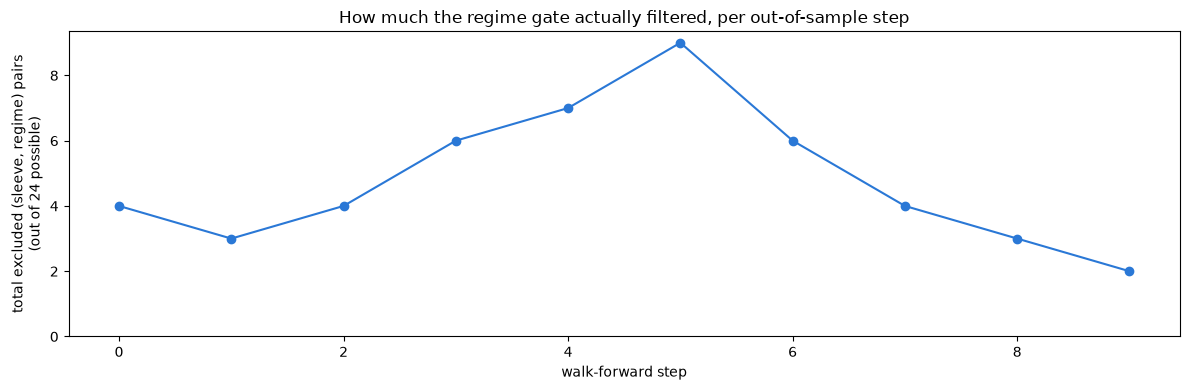

total_excluded_regimes across steps: min=2, max=9, mean=4.8


In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wf_results["step"], wf_results["total_excluded_regimes"], marker="o", color="#2a78d6")
ax.set_xlabel("walk-forward step")
ax.set_ylabel("total excluded (sleeve, regime) pairs\n(out of 24 possible)")
ax.set_title("How much the regime gate actually filtered, per out-of-sample step")
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

print(f"total_excluded_regimes across steps: min={wf_results['total_excluded_regimes'].min()}, "
      f"max={wf_results['total_excluded_regimes'].max()}, mean={wf_results['total_excluded_regimes'].mean():.1f}")


## Findings

*(placeholder -- rewritten after execution with real numbers)*


## Findings

**The suspicion was correct: the single-split "every metric improves"
result was substantially inflated by fitting the gate to its own evaluation
data. Honestly walk-forward tested, the regime filter provides a real but
small edge on top of an already-strong, independently-confirmed combined
portfolio -- not the dramatic free lunch the full-history number showed.**

| | trades | win_rate | trade_sharpe | trade_sharpe_lb | sum_pnl |
|---|---|---|---|---|---|
| Filtered (regime-gated OOS) | 3,707 | 49.3% | 0.097 | **+0.0697** | +434.0% |
| Unfiltered (OOS) | 4,409 | 47.6% | 0.089 | **+0.0645** | +475.3% |

**First, the good news buried in this table**: the *unfiltered* combined
6-sleeve portfolio walk-forward-confirms on its own, at `trade_sharpe_lb`=
+0.0645 -- pooled entirely from genuinely out-of-sample trades. That's
stronger than every single-sleeve walk-forward result in this program
except the Bollinger MR sleeves themselves. This wasn't previously tested
this rigorously (the original `combination.ipynb` never walk-forward
validated the combined portfolio itself, only its component sleeves
individually) -- worth remembering on its own.

**Second, the regime filter's actual out-of-sample edge**: `trade_sharpe_lb`
improves from +0.0645 to +0.0697 -- about an 8% relative improvement, real
and in the right direction, but nowhere close to the in-sample story (net
return +172%->+290%, Sharpe 0.67->0.91, every metric moving at once).
Interestingly, filtered has a *higher* lower bound despite *lower* raw
summed pnl (+434.0% vs +475.3%) -- the filter is trading some raw return for
reduced variance, a smaller and more honest version of the trade-off
`low_corr_pair_with_regime_filter.ipynb`'s "top 50%" rule showed more
starkly.

**Step-level, it's close to a coin flip**: filtered beat unfiltered on net
return in 5 of 10 steps, unfiltered beat filtered in the other 5. Neither
side dominates consistently.

**The clearest sign the original rule doesn't generalize as a fixed rule**:
`total_excluded_regimes` per step (how many of the 24 possible (sleeve,
regime) pairs got excluded that window) ranged from **2 to 9** (mean 4.8)
across the 10 training windows -- the original full-history analysis found
exactly **2** exclusions (MNQ Donchian x Choppy/High-Vol, MNQ SuperTrend x
Trending/High-Vol) and treated that as *the* answer. Different 24-month
windows identify substantially different regimes as "bad" for different
sleeves -- the same kind of parameter instability this pipeline's numeric
walk-forwards have repeatedly used as an independent red flag alongside a
weak lower bound (e.g. MES MACD-MR's wandering `sl_percent`, MES Bollinger-
squeeze's wandering `bb_length`).

**Bottom line -- three separate, honest conclusions, not one**:
1. The combined 6-sleeve portfolio itself (no regime filter at all) has a
   real, walk-forward-confirmed edge -- this is now more rigorously
   validated than it was before this notebook existed.
2. Regime-gating adds a small, real, correctly-signed improvement on top of
   that (+0.0645 -> +0.0697), not the dramatic single-split result.
3. The *specific* regime-exclusion rule from the original full-history
   analysis (exactly 2 exclusions, MNQ Donchian/Choppy-High-Vol and MNQ
   SuperTrend/Trending-High-Vol) should **not** be treated as a fixed,
   permanent rule -- a real deployment would need to re-derive it
   periodically on rolling data, the same way this notebook did, rather
   than hard-coding what one historical sample happened to show.